In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
COACH_DIR = Path("/Users/hyeon/SeSAC_Project/Coach")    # Coach의 절대경로 입력
RUN_FOLDER = "test10"
RUN_DIR = COACH_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)

# 피처 추출을 위한 값 계산



In [31]:
ps.cal_stride()

,frame,value,class
2,7,-1.565279,0
1,20,93.068842,1
3,26,-6.318001,0


In [34]:
len(ps.strides)

3

In [4]:
ps.strides

,frame,value,class
4,16,-1.562579,0
2,27,39.605296,1
3,35,17.782975,0
1,49,93.557994,1
4,65,-6.002575,0


In [29]:
len(ps.gct())

1

In [22]:
a = 1

In [27]:
np.asarray(a).reshape(-1)[0]

np.int64(1)

In [ ]:
ps.strides.iloc[:4].loc[4].frame

TypeError: 'numpy.float64' object is not an iterator

In [6]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1566.204346,824.780731,1885.789673,131.141235,1606.326179,748.913948,1618.744856,761.332625,1607.455149,763.590566,...,1618.744856,150.559518,1871.634288,214.910843,1621.002797,153.946430,1869.376346,299.583640,1710.191481,160.720253
1,1558.756836,809.283539,1868.142700,131.089966,1585.405339,745.040621,1597.547477,757.182759,1585.405339,758.286589,...,1618.520262,152.283516,1842.597906,203.059730,1621.831754,156.698839,1838.182583,294.677681,1709.034384,161.114162
2,1544.564941,807.803619,1829.895386,128.031921,1565.526299,745.624009,1578.803091,757.794402,1566.632698,758.900801,...,1617.527067,151.487586,1808.934150,202.381954,1624.165463,155.913184,1807.827751,286.468301,1702.719815,158.125982
3,1412.392090,804.579803,1802.677368,127.116516,1547.991997,747.021870,1561.223701,759.150932,1550.197281,761.356216,...,1616.355804,150.492516,1766.315125,190.187630,1625.176941,156.005726,1776.238903,262.962006,1697.951317,158.211010
4,1409.595337,806.982117,1764.418335,129.436890,1529.662517,749.417203,1541.793046,761.547733,1531.868068,762.650508,...,1617.884546,150.610153,1722.648205,189.207293,1624.501198,156.124030,1742.498162,259.784919,1692.873271,158.329581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,109.225418,792.956787,401.628021,132.773071,180.210483,739.015985,190.955661,748.686645,185.583072,751.910198,...,368.251094,206.055192,174.837894,150.180271,380.070790,217.874887,255.426727,159.850930,363.953023,304.910823
74,94.365807,791.317200,313.994934,137.031372,160.518724,735.728498,170.102988,746.377682,165.843315,748.507518,...,330.905653,201.139482,175.427580,151.088319,339.424999,218.178175,247.842025,161.737502,330.905653,295.917216
75,69.426704,791.452332,290.821320,136.465210,140.679797,736.870036,151.340395,747.530633,144.944036,749.662753,...,283.531804,197.443803,176.925829,149.471114,293.126342,212.368640,253.682131,163.329891,301.654819,286.992822
76,48.431145,793.649048,289.958832,129.179810,122.690795,740.439597,131.342739,752.336019,128.098260,753.417512,...,243.818006,195.367175,178.928429,148.862980,248.143978,206.182104,249.225471,164.003881,273.018316,272.153171


In [7]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0025383889813480466 / pixel 입니다.


np.float64(673.655618805862)

In [8]:
a = np.array([1, 2 ,3])

In [9]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0025383889813480466 / pixel 입니다.


np.float64(673.655618805862)

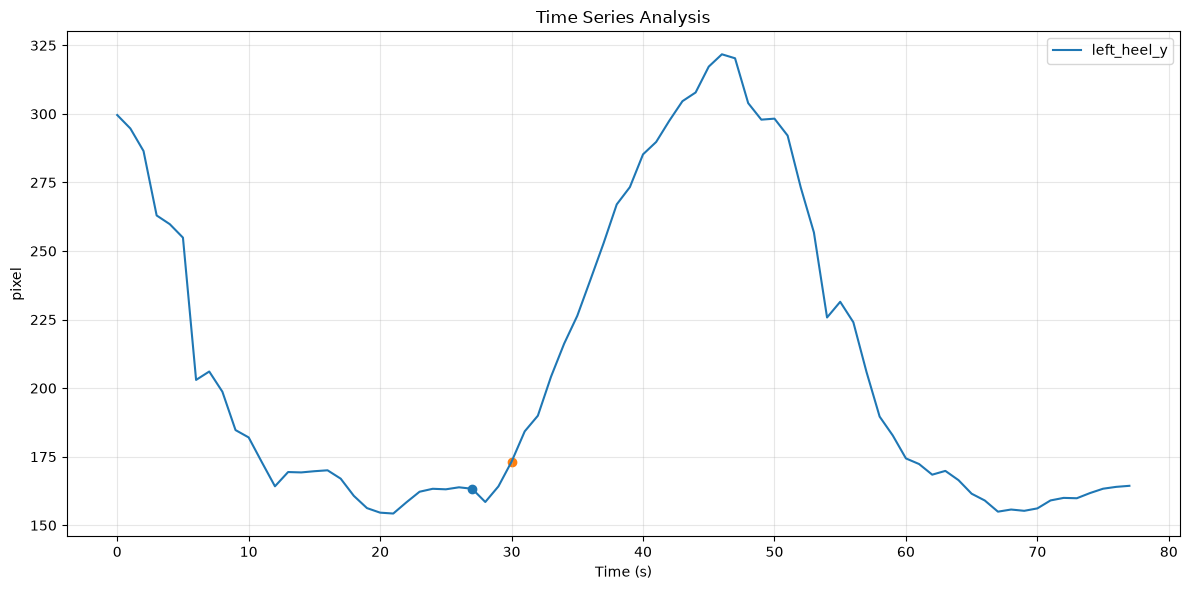

In [10]:
visualize_frame(ps.df[["left_heel_y"]], [27, 30])

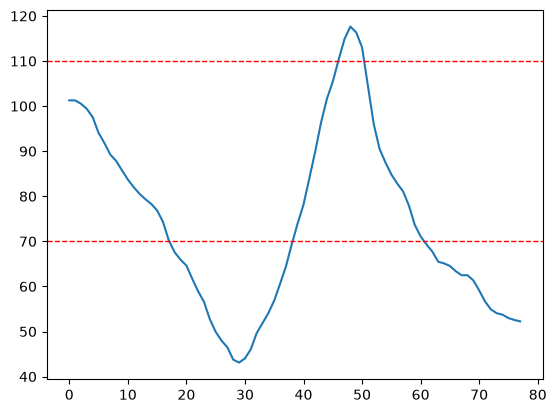

In [11]:
plt.plot(ps.joint_angle("left_elbow", smooth=True))
plt.axhline(y=70, color="red", linestyle="--", linewidth=1)
plt.axhline(y=110, color="red", linestyle="--", linewidth=1)

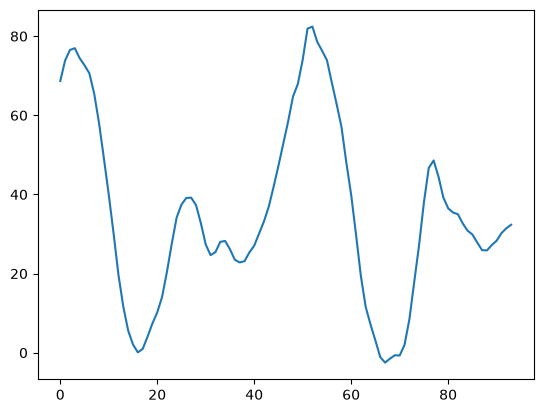

In [ ]:
plt.plot(ps.joint_angle("left_knee", smooth=True, negative=True))

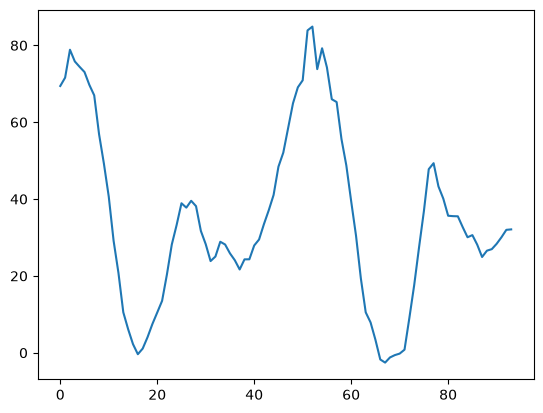

In [ ]:
plt.plot(ps.joint_angle(("left_hip", "left_knee", "left_ankle"), negative=True))

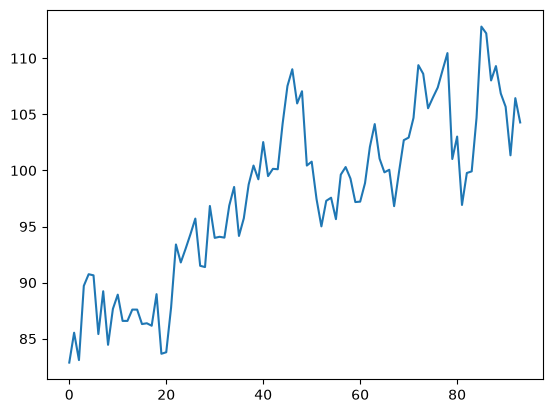

In [ ]:
plt.plot(ps.joint_angle(("nose", "left_ear", "neck")))

In [ ]:
ps.cal_stride()
ps.pixel2m()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1      3  76.975644      1
4     16   0.091345      0
2     27  39.190298      1
3     37  22.818946      0
1     52  82.430869      1
4     67  -2.495341      0
2     77  48.592180      1
사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0023180223572492106 / pixel 입니다.


In [ ]:
ps.cal_stride()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1      3  76.975644      1
4     16   0.091345      0
2     27  39.190298      1
3     37  22.818946      0
1     52  82.430869      1
4     67  -2.495341      0
2     77  48.592180      1


In [17]:
n = 0
while True:
    assert 0, "1"


AssertionError: 1

In [15]:
n

10